In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, classification_report

D:\Anaconda\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
X_train = np.load("D:/PomegranateGuard/dataset/X_train.npy")
X_val   = np.load("D:/PomegranateGuard/dataset/X_val.npy")
X_test  = np.load("D:/PomegranateGuard/dataset/X_test.npy")

y_train = np.load("D:/PomegranateGuard/dataset/y_train.npy")
y_val   = np.load("D:/PomegranateGuard/dataset/y_val.npy")
y_test  = np.load("D:/PomegranateGuard/dataset/y_test.npy")

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

num_classes = 4

Train: (3938, 224, 224, 3)
Validation: (844, 224, 224, 3)
Test: (844, 224, 224, 3)


In [3]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [4]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 116s 845ms/step - accuracy: 0.9020 - loss: 0.2741 - val_accuracy: 0.9716 - val_loss: 0.0892
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 104s 837ms/step - accuracy: 0.9614 - loss: 0.1210 - val_accuracy: 0.9739 - val_loss: 0.0785
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 100s 805ms/step - accuracy: 0.9713 - loss: 0.0839 - val_accuracy: 0.9787 - val_loss: 0.0674
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 103s 827ms/step - accuracy: 0.9736 - loss: 0.0728 - val_accuracy: 0.9775 - val_loss: 0.0669
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 102s 822ms/step - accuracy: 0.9766 - loss: 0.0618 - val_accuracy: 0.9822 - val_loss: 0.0530
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 102s 822ms/step - accuracy: 0.9837 - loss: 0.0456 - val_accuracy: 0.9799 - val_loss: 0.0628
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 102s 821ms/step - accuracy: 0.9837 - loss: 0.0394 - val_accuracy: 0.9787 - val_loss: 0.0580
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 102s 823ms/step - accuracy: 0.9853 -

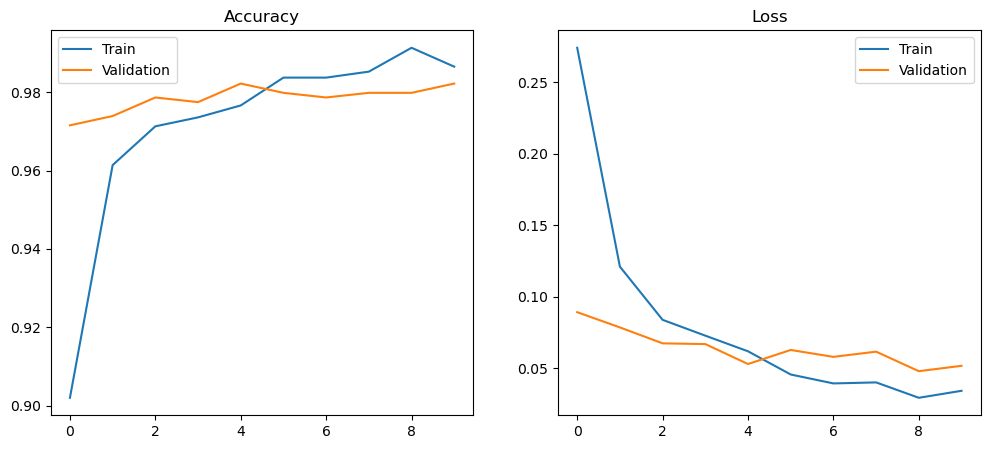

In [5]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.savefig("D:/PomegranateGuard/training/feature_extractor_training.png")
plt.show()

In [6]:

model.save("D:/PomegranateGuard/model/pomegranate_feature_extractor.h5")

print("Feature extractor model saved!")

test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

Feature extractor model saved!
27/27 ━━━━━━━━━━━━━━━━━━━━ 19s 693ms/step - accuracy: 0.9834 - loss: 0.0405
Test Accuracy: 0.9834123253822327
Test Loss: 0.04046204686164856


27/27 ━━━━━━━━━━━━━━━━━━━━ 22s 733ms/step


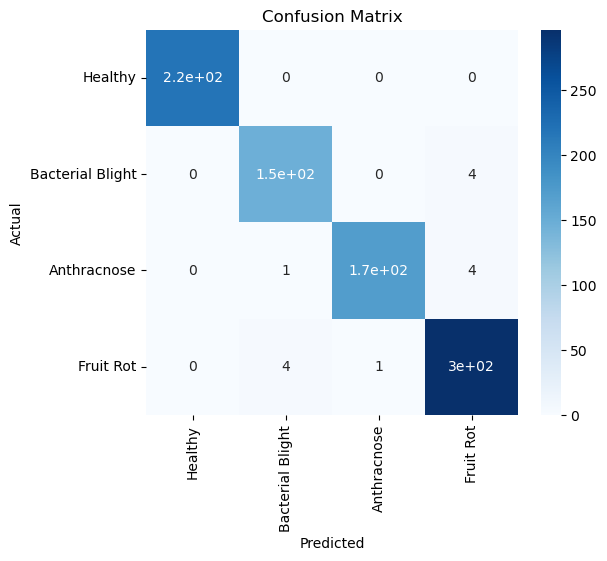

In [7]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = ["Healthy", "Bacterial Blight", "Anthracnose", "Fruit Rot"]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("D:/PomegranateGuard/evaluation/feature_extractor_cm.png")
plt.show()

In [8]:
report = classification_report(y_test, y_pred, target_names=class_names)

print(report)

with open("D:/PomegranateGuard/evaluation/feature_extractor_report.txt","w") as f:
    f.write(report)

                  precision    recall  f1-score   support

         Healthy       1.00      1.00      1.00       218
Bacterial Blight       0.97      0.97      0.97       150
     Anthracnose       0.99      0.97      0.98       175
       Fruit Rot       0.97      0.98      0.98       301

        accuracy                           0.98       844
       macro avg       0.98      0.98      0.98       844
    weighted avg       0.98      0.98      0.98       844

